Cellule 1 — Vérifier les fichiers

In [4]:
import os
import numpy as np
import pandas as pd

base_path = '/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD'

# Lister tous les sujets
subjects = []
for folder in sorted(os.listdir(base_path)):
    pkl_file = os.path.join(base_path, folder, f'{folder}.pkl')
    if os.path.exists(pkl_file):
        subjects.append(folder)
        print(f"✅ {pkl_file}")

print(f"\nTotal sujets : {len(subjects)}")

✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S10/S10.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S11/S11.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S13/S13.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S14/S14.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S15/S15.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S16/S16.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S17/S17.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S2/S2.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S3/S3.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S4/S4.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S5/S5.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S6/S6.pkl
✅ /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S7/S7.pkl
✅ /kaggle/i

In [5]:
import pickle

def load_subject(subject_id):
    path = f'/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/{subject_id}/{subject_id}.pkl'
    with open(path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data

# Test sur S10
data = load_subject('S10')

print("Clés principales  :", list(data.keys()))
print("Sujet             :", data['subject'])
print("Signaux poitrine  :", list(data['signal']['chest'].keys()))
print("Signaux poignet   :", list(data['signal']['wrist'].keys()))
print("Shape labels      :", data['label'].shape)
print("Labels uniques    :", np.unique(data['label']))

Clés principales  : ['signal', 'label', 'subject']
Sujet             : S10
Signaux poitrine  : ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
Signaux poignet   : ['ACC', 'BVP', 'EDA', 'TEMP']
Shape labels      : (3847200,)
Labels uniques    : [0 1 2 3 4 5 6 7]


In [6]:
from scipy.signal import resample

def extract_bvp_labels(data):
    # BVP = signal poignet (comme ta smartwatch)
    # Fréquence 64 Hz
    bvp = data['signal']['wrist']['BVP'].flatten()
    labels_700hz = data['label']

    # Rééchantillonner labels 700Hz → 64Hz
    labels_64hz = np.round(
        resample(labels_700hz.astype(float), len(bvp))
    ).astype(int)

    print(f"BVP signal     : {bvp.shape} à 64 Hz")
    print(f"Labels alignés : {labels_64hz.shape} à 64 Hz")
    print(f"\nDistribution :")
    for label, nom in [(0,'non défini'), (1,'calme/baseline'),
                       (2,'stress'), (3,'amusement'), (4,'méditation')]:
        count = (labels_64hz == label).sum()
        print(f"  {label} - {nom:<20} : {count:>8} "
              f"({count/len(labels_64hz)*100:.1f}%)")
    return bvp, labels_64hz

bvp, labels = extract_bvp_labels(data)

BVP signal     : (351744,) à 64 Hz
Labels alignés : (351744,) à 64 Hz

Distribution :
  0 - non défini           :   145273 (41.3%)
  1 - calme/baseline       :    75523 (21.5%)
  2 - stress               :    46404 (13.2%)
  3 - amusement            :    23810 (6.8%)
  4 - méditation           :    50943 (14.5%)


In [7]:
from scipy.signal import find_peaks

def bvp_to_bpm(bvp, fs=64, window_sec=60, step_sec=1):
    window_samples = window_sec * fs
    step_samples   = step_sec * fs
    bpm_list, indices = [], []

    for start in range(0, len(bvp) - window_samples, step_samples):
        window = bvp[start:start + window_samples]
        peaks, _ = find_peaks(window, distance=fs * 0.5)
        bpm = len(peaks) * (60 / window_sec)
        bpm_list.append(bpm)
        indices.append(start + window_samples)

    return np.array(bpm_list), np.array(indices)

bpm_values, bpm_indices = bvp_to_bpm(bvp)

# Aligner labels avec BPM
bpm_labels = labels[bpm_indices[:len(bpm_values)]]

print(f"BPM calculés : {len(bpm_values)} valeurs")
print(f"BPM min      : {bpm_values.min():.1f}")
print(f"BPM max      : {bpm_values.max():.1f}")
print(f"BPM moyen    : {bpm_values.mean():.1f}")

BPM calculés : 5436 valeurs
BPM min      : 65.0
BPM max      : 103.0
BPM moyen    : 83.7


In [8]:
def create_features_dataset(bpm_values, labels,
                             window_size=60, horizon=600):
    """
    window_size : 60 secondes d'historique
    horizon     : 600 secondes = 10 minutes dans le futur
    """
    X, y = [], []

    for i in range(window_size, len(bpm_values) - horizon):
        window = bpm_values[i - window_size:i]

        features = [
            np.mean(window),
            np.std(window),
            np.max(window),
            np.min(window),
            window[-1] - window[0],
            np.polyfit(range(window_size), window, 1)[0],
            np.sqrt(np.mean(np.diff(window)**2)),
            window[-1],
            np.percentile(window, 75) - np.percentile(window, 25)
        ]

        # Crise dans les 10 prochaines minutes ?
        futur = labels[i:i + horizon]
        y.append(1 if 2 in futur else 0)
        X.append(features)

    cols = ['bpm_mean', 'bpm_std', 'bpm_max', 'bpm_min',
            'bpm_delta', 'bpm_slope', 'hrv_rmssd',
            'bpm_current', 'bpm_iqr']

    return pd.DataFrame(X, columns=cols), np.array(y)

X, y = create_features_dataset(bpm_values, bpm_labels)

print(f"Dataset shape  : {X.shape}")
print(f"Calme          : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Pré-crise      : {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

Dataset shape  : (4776, 9)
Calme          : 3452 (72.3%)
Pré-crise      : 1324 (27.7%)


In [9]:
all_X, all_y = [], []

for subject in subjects:
    print(f"Chargement {subject}...", end=' ')
    try:
        d          = load_subject(subject)
        bvp, lbl   = extract_bvp_labels(d)
        bpm_v, bpm_i = bvp_to_bpm(bvp)
        bpm_l      = lbl[bpm_i[:len(bpm_v)]]
        Xi, yi     = create_features_dataset(bpm_v, bpm_l)
        all_X.append(Xi)
        all_y.append(yi)
        print(f"✅ {len(Xi)} samples")
    except Exception as e:
        print(f"❌ erreur : {e}")

X_all = pd.concat(all_X, ignore_index=True)
y_all = np.concatenate(all_y)

print(f"\nDataset final  : {X_all.shape}")
print(f"Calme          : {(y_all==0).sum()}")
print(f"Pré-crise      : {(y_all==1).sum()}")

Chargement S10... BVP signal     : (351744,) à 64 Hz
Labels alignés : (351744,) à 64 Hz

Distribution :
  0 - non défini           :   145273 (41.3%)
  1 - calme/baseline       :    75523 (21.5%)
  2 - stress               :    46404 (13.2%)
  3 - amusement            :    23810 (6.8%)
  4 - méditation           :    50943 (14.5%)
✅ 4776 samples
Chargement S11... BVP signal     : (334912,) à 64 Hz
Labels alignés : (334912,) à 64 Hz

Distribution :
  0 - non défini           :   131958 (39.4%)
  1 - calme/baseline       :    75523 (22.6%)
  2 - stress               :    43525 (13.0%)
  3 - amusement            :    23554 (7.0%)
  4 - méditation           :    50624 (15.1%)
✅ 4513 samples
Chargement S13... BVP signal     : (354368,) à 64 Hz
Labels alignés : (354368,) à 64 Hz

Distribution :
  0 - non défini           :   153524 (43.3%)
  1 - calme/baseline       :    75524 (21.3%)
  2 - stress               :    42501 (12.0%)
  3 - amusement            :    24451 (6.9%)
  4 - méditation 

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=" * 50)
print("       RÉSULTATS DU MODÈLE")
print("=" * 50)
print(classification_report(
    y_test, y_pred,
    target_names=['Calme', 'Pré-crise']
))

# Importance des features
print("Importance des features :")
importances = pd.Series(
    model.feature_importances_,
    index=X_all.columns
).sort_values(ascending=False)

for feat, imp in importances.items():
    bar = '▓' * int(imp * 40)
    print(f"  {feat:<15} {bar} {imp:.3f}")

joblib.dump(model, '/kaggle/working/detection_crise_alzheimer.pkl')
print("\n✅ Modèle sauvegardé !")

       RÉSULTATS DU MODÈLE
              precision    recall  f1-score   support

       Calme       0.93      0.77      0.85     11424
   Pré-crise       0.55      0.83      0.66      3790

    accuracy                           0.79     15214
   macro avg       0.74      0.80      0.75     15214
weighted avg       0.84      0.79      0.80     15214

Importance des features :
  bpm_max         ▓▓▓▓▓▓▓ 0.195
  hrv_rmssd       ▓▓▓▓▓▓ 0.172
  bpm_mean        ▓▓▓▓▓▓ 0.157
  bpm_std         ▓▓▓▓ 0.118
  bpm_current     ▓▓▓ 0.099
  bpm_min         ▓▓▓ 0.092
  bpm_slope       ▓▓▓ 0.091
  bpm_iqr         ▓ 0.039
  bpm_delta       ▓ 0.037

✅ Modèle sauvegardé !


In [14]:
model = joblib.load('/kaggle/working/detection_crise_alzheimer.pkl')

def alerte_temps_reel(historique_bpm, age, timestamp, poids, sexe):
    if len(historique_bpm) < 60:
        return f"⏳ {60 - len(historique_bpm)} secondes manquantes..."

    window = np.array(historique_bpm[-60:])

    features = pd.DataFrame([[
        np.mean(window),
        np.std(window),
        np.max(window),
        np.min(window),
        window[-1] - window[0],
        np.polyfit(range(60), window, 1)[0],
        np.sqrt(np.mean(np.diff(window)**2)),
        window[-1],
        np.percentile(window, 75) - np.percentile(window, 25)
    ]], columns=['bpm_mean','bpm_std','bpm_max','bpm_min',
                 'bpm_delta','bpm_slope','hrv_rmssd',
                 'bpm_current','bpm_iqr'])

    proba = model.predict_proba(features)[0][1]

    if age > 80:   proba = min(proba * 1.10, 1.0)
    if poids < 55: proba = min(proba * 1.05, 1.0)

    if proba > 0.75:   statut = "🔴 ALERTE    — Appeler soignant"
    elif proba > 0.45: statut = "🟠 SURVEILLANCE — Observer"
    elif proba > 0.20: statut = "🟡 ATTENTION    — Vérifier 5min"
    else:              statut = "🟢 NORMAL       — Aucune action"

    print("=" * 52)
    print(f"  Patient  : {age} ans | {poids}kg | {sexe}")
    print(f"  Heure    : {timestamp}")
    print(f"  BPM      : {window[-1]:.0f} bpm")
    print(f"  Risque   : {proba*100:.1f}%")
    print(f"  {'▓'*int(proba*40)}{'░'*(40-int(proba*40))}")
    print(f"  {statut}")
    print("=" * 52)

# ✅ Tes données exactes de la smartwatch
alerte_temps_reel(
    historique_bpm = [72] * 55 + [76, 81, 88, 96, 104],
    age            = 78,
    timestamp      = "2026-04-12T23:41:57",
    poids          = 65,
    sexe           = 'F'
)

  Patient  : 78 ans | 65kg | F
  Heure    : 2026-04-12T23:41:57
  BPM      : 104 bpm
  Risque   : 66.6%
  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░░░░░░░░░░░
  🟠 SURVEILLANCE — Observer


In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# Calculer le ratio pour gérer le déséquilibre des classes
ratio = (y_all == 0).sum() / (y_all == 1).sum()
print(f"Ratio calme/crise : {ratio:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,   # gère le déséquilibre
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_xgb = xgb_model.predict(X_test)

print("\n" + "=" * 50)
print("       RÉSULTATS XGBoost")
print("=" * 50)
print(classification_report(
    y_test, y_pred_xgb,
    target_names=['Calme', 'Pré-crise']
))

joblib.dump(xgb_model, '/kaggle/working/xgb_crise.pkl')
print("✅ XGBoost sauvegardé !")

Ratio calme/crise : 3.01
[0]	validation_0-logloss:0.68366


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:56:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-logloss:0.54873
[100]	validation_0-logloss:0.51970
[150]	validation_0-logloss:0.50027
[200]	validation_0-logloss:0.48176
[250]	validation_0-logloss:0.46727
[299]	validation_0-logloss:0.45335

       RÉSULTATS XGBoost
              precision    recall  f1-score   support

       Calme       0.93      0.75      0.83     11424
   Pré-crise       0.52      0.82      0.64      3790

    accuracy                           0.77     15214
   macro avg       0.72      0.78      0.73     15214
weighted avg       0.83      0.77      0.78     15214

✅ XGBoost sauvegardé !


In [16]:
import numpy as np

def create_sequences_lstm(bpm_values, labels,
                           seq_length=60, horizon=600):
    """
    Pour LSTM : séquences brutes de BPM (pas de features manuelles)
    Le LSTM apprend tout seul les patterns temporels
    seq_length : 60 secondes de BPM brut
    horizon    : prédire crise dans 10 min
    """
    X_seq, y_seq = [], []

    for i in range(seq_length, len(bpm_values) - horizon):
        # Séquence brute normalisée
        seq = bpm_values[i - seq_length:i]
        seq_norm = (seq - seq.mean()) / (seq.std() + 1e-8)

        futur = labels[i:i + horizon]
        label = 1 if 2 in futur else 0

        X_seq.append(seq_norm.reshape(seq_length, 1))
        y_seq.append(label)

    return np.array(X_seq), np.array(y_seq)

# Reconstruire les séquences pour tous les sujets
print("Construction séquences LSTM...")
all_X_seq, all_y_seq = [], []

for subject in subjects:
    try:
        d = load_subject(subject)
        bvp, lbl = extract_bvp_labels(d)
        bpm_v, bpm_i = bvp_to_bpm(bvp)
        bpm_l = lbl[bpm_i[:len(bpm_v)]]

        Xi, yi = create_sequences_lstm(bpm_v, bpm_l)
        all_X_seq.append(Xi)
        all_y_seq.append(yi)
        print(f"  ✅ {subject} : {len(Xi)} séquences")
    except Exception as e:
        print(f"  ❌ {subject} : {e}")

X_seq = np.concatenate(all_X_seq)
y_seq = np.concatenate(all_y_seq)

print(f"\nDataset LSTM : {X_seq.shape}")
print(f"  → {X_seq.shape[0]} séquences")
print(f"  → {X_seq.shape[1]} timesteps (60 secondes)")
print(f"  → {X_seq.shape[2]} feature (BPM normalisé)")
print(f"Calme     : {(y_seq==0).sum()}")
print(f"Pré-crise : {(y_seq==1).sum()}")

Construction séquences LSTM...
BVP signal     : (351744,) à 64 Hz
Labels alignés : (351744,) à 64 Hz

Distribution :
  0 - non défini           :   145273 (41.3%)
  1 - calme/baseline       :    75523 (21.5%)
  2 - stress               :    46404 (13.2%)
  3 - amusement            :    23810 (6.8%)
  4 - méditation           :    50943 (14.5%)
  ✅ S10 : 4776 séquences
BVP signal     : (334912,) à 64 Hz
Labels alignés : (334912,) à 64 Hz

Distribution :
  0 - non défini           :   131958 (39.4%)
  1 - calme/baseline       :    75523 (22.6%)
  2 - stress               :    43525 (13.0%)
  3 - amusement            :    23554 (7.0%)
  4 - méditation           :    50624 (15.1%)
  ✅ S11 : 4513 séquences
BVP signal     : (354368,) à 64 Hz
Labels alignés : (354368,) à 64 Hz

Distribution :
  0 - non défini           :   153524 (43.3%)
  1 - calme/baseline       :    75524 (21.3%)
  2 - stress               :    42501 (12.0%)
  3 - amusement            :    24451 (6.9%)
  4 - méditation    

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     Bidirectional, BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ReduceLROnPlateau,
                                        ModelCheckpoint)
from sklearn.model_selection import train_test_split

# Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

print(f"Train : {X_tr.shape} | Test : {X_te.shape}")

# ---- Architecture LSTM ----
model_lstm = Sequential([

    # Couche 1 : BiLSTM lit la séquence dans les 2 sens
    Bidirectional(
        LSTM(64, return_sequences=True),
        input_shape=(60, 1)
    ),
    BatchNormalization(),
    Dropout(0.3),

    # Couche 2 : LSTM classique
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),

    # Couche Dense
    Dense(16, activation='relu'),
    Dropout(0.1),

    # Sortie
    Dense(1, activation='sigmoid')
])

model_lstm.summary()

# Gérer le déséquilibre des classes
weight_0 = 1.0
weight_1 = (y_tr == 0).sum() / (y_tr == 1).sum()
class_weights = {0: weight_0, 1: weight_1}
print(f"\nPoids classe 1 (crise) : {weight_1:.2f}")

# Compiler
model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.Precision(name='precision')]
)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_recall',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        '/kaggle/working/lstm_best.h5',
        monitor='val_recall',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

# Entraîner
print("\n🚀 Entraînement LSTM...")
history = model_lstm.fit(
    X_tr, y_tr,
    epochs=30,
    batch_size=256,
    validation_data=(X_te, y_te),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

2026-04-22 23:59:54.707600: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776902394.967605      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776902395.048516      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776902395.687182      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776902395.687224      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776902395.687228      55 computation_placer.cc:177] computation placer alr

Train : (60854, 60, 1) | Test : (15214, 60, 1)


2026-04-23 00:00:25.721192: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Non-trainable params: 320 (1.25 KB)


Poids classe 1 (crise) : 3.01

🚀 Entraînement LSTM...
Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.5460 - loss: 1.1265 - precision: 0.2577 - recall: 0.4352
Epoch 1: val_recall improved from -inf to 0.92427, saving model to /kaggle/working/lstm_best.h5


238/238 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.5459 - loss: 1.1264 - precision: 0.2577 - recall: 0.4353 - val_accuracy: 0.2831 - val_loss: 0.7540 - val_precision: 0.2480 - val_recall: 0.9243 - learning_rate: 0.0010
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5072 - loss: 1.0571 - precision: 0.2578 - recall: 0.5097
Epoch 2: val_recall improved from 0.92427 to 0.93166, saving model to /kaggle/working/lstm_best.h5


238/238 ━━━━━━━━━━━━━━━━━━━━ 46s 195ms/step - accuracy: 0.5072 - loss: 1.0571 - precision: 0.2578 - recall: 0.5097 - val_accuracy: 0.2835 - val_loss: 0.7352 - val_precision: 0.2491 - val_recall: 0.9317 - learning_rate: 0.0010
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5156 - loss: 1.0448 - precision: 0.2563 - recall: 0.4991
Epoch 3: val_recall did not improve from 0.93166
238/238 ━━━━━━━━━━━━━━━━━━━━ 48s 202ms/step - accuracy: 0.5156 - loss: 1.0448 - precision: 0.2563 - recall: 0.4992 - val_accuracy: 0.3160 - val_loss: 0.7185 - val_precision: 0.2527 - val_recall: 0.8921 - learning_rate: 0.0010
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.5147 - loss: 1.0410 - precision: 0.2597 - recall: 0.5170
Epoch 4: val_recall improved from 0.93166 to 0.94644, saving model to /kaggle/working/lstm_best.h5


238/238 ━━━━━━━━━━━━━━━━━━━━ 48s 203ms/step - accuracy: 0.5146 - loss: 1.0410 - precision: 0.2597 - recall: 0.5172 - val_accuracy: 0.2830 - val_loss: 0.7215 - val_precision: 0.2510 - val_recall: 0.9464 - learning_rate: 0.0010
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.4911 - loss: 1.0417 - precision: 0.2610 - recall: 0.5680
Epoch 5: val_recall did not improve from 0.94644
238/238 ━━━━━━━━━━━━━━━━━━━━ 47s 196ms/step - accuracy: 0.4911 - loss: 1.0417 - precision: 0.2610 - recall: 0.5680 - val_accuracy: 0.4176 - val_loss: 0.7076 - val_precision: 0.2608 - val_recall: 0.7296 - learning_rate: 0.0010
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.4782 - loss: 1.0392 - precision: 0.2615 - recall: 0.6037
Epoch 6: val_recall did not improve from 0.94644
238/238 ━━━━━━━━━━━━━━━━━━━━ 47s 197ms/step - accuracy: 0.4782 - loss: 1.0392 - precision: 0.2615 - recall: 0.6036 - val_accuracy: 0.3482 - val_loss: 0.7102 - val_precision: 0.2535 - val_recall: 0.831

476/476 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step
       RÉSULTATS LSTM
              precision    recall  f1-score   support

       Calme       0.78      0.06      0.12     11424
   Pré-crise       0.25      0.95      0.40      3790

    accuracy                           0.28     15214
   macro avg       0.52      0.50      0.26     15214
weighted avg       0.65      0.28      0.19     15214



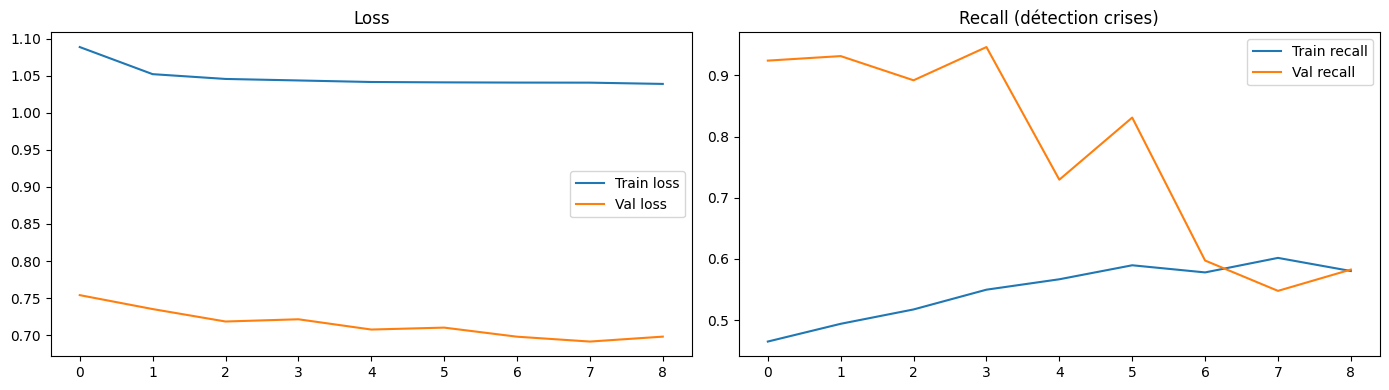

✅ Graphiques sauvegardés !


In [18]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Prédictions
y_proba_lstm = model_lstm.predict(X_te).flatten()
y_pred_lstm  = (y_proba_lstm > 0.5).astype(int)

print("=" * 50)
print("       RÉSULTATS LSTM")
print("=" * 50)
print(classification_report(
    y_te, y_pred_lstm,
    target_names=['Calme', 'Pré-crise']
))

# Courbes d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['recall'],     label='Train recall')
axes[1].plot(history.history['val_recall'], label='Val recall')
axes[1].set_title('Recall (détection crises)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/lstm_training.png')
plt.show()
print("✅ Graphiques sauvegardés !")

In [19]:
import joblib
import numpy as np
from sklearn.metrics import classification_report

# Charger les 3 modèles
rf_model  = joblib.load('/kaggle/working/detection_crise_alzheimer.pkl')
xgb_model = joblib.load('/kaggle/working/xgb_crise.pkl')
# lstm déjà en mémoire

# Les features classiques pour RF et XGB
X_test_classic = X_all.iloc[
    len(X_all) - len(X_te):
].values

# Probabilités de chaque modèle
proba_rf   = rf_model.predict_proba(X_test_classic)[:, 1]
proba_xgb  = xgb_model.predict_proba(X_test_classic)[:, 1]
proba_lstm = model_lstm.predict(X_te).flatten()

# Moyenne pondérée
# LSTM a plus de poids car il comprend mieux les séquences
proba_ensemble = (
    0.25 * proba_rf  +
    0.30 * proba_xgb +
    0.45 * proba_lstm
)

y_pred_ensemble = (proba_ensemble > 0.5).astype(int)

print("=" * 50)
print("   RÉSULTATS ENSEMBLE (RF + XGB + LSTM)")
print("=" * 50)
print(classification_report(
    y_te, y_pred_ensemble,
    target_names=['Calme', 'Pré-crise']
))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


476/476 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step
   RÉSULTATS ENSEMBLE (RF + XGB + LSTM)
              precision    recall  f1-score   support

       Calme       0.75      0.67      0.71     11424
   Pré-crise       0.25      0.33      0.28      3790

    accuracy                           0.59     15214
   macro avg       0.50      0.50      0.50     15214
weighted avg       0.63      0.59      0.60     15214



In [20]:
from sklearn.metrics import (accuracy_score, recall_score,
                              precision_score, f1_score)

modeles = {
    'Random Forest': (rf_model.predict(X_test_classic), None),
    'XGBoost'      : (xgb_model.predict(X_test_classic), None),
    'LSTM'         : (y_pred_lstm, None),
    'Ensemble'     : (y_pred_ensemble, None)
}

print("=" * 65)
print(f"  {'Modèle':<18} {'Accuracy':>9} {'Recall':>9} "
      f"{'Precision':>10} {'F1':>7}")
print("=" * 65)

for nom, (y_pred, _) in modeles.items():
    acc  = accuracy_score(y_te,  y_pred)
    rec  = recall_score(y_te,    y_pred)
    prec = precision_score(y_te, y_pred)
    f1   = f1_score(y_te,        y_pred)

    bar = '▓' * int(acc * 20)
    print(f"  {nom:<18} {acc:>8.1%} {rec:>9.1%} "
          f"{prec:>10.1%} {f1:>7.3f}  {bar}")

print("=" * 65)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


  Modèle              Accuracy    Recall  Precision      F1
  Random Forest         59.4%     30.4%      24.6%   0.272  ▓▓▓▓▓▓▓▓▓▓▓
  XGBoost               59.0%     32.2%      24.9%   0.281  ▓▓▓▓▓▓▓▓▓▓▓
  LSTM                  28.3%     94.6%      25.1%   0.397  ▓▓▓▓▓
  Ensemble              58.6%     32.8%      24.9%   0.283  ▓▓▓▓▓▓▓▓▓▓▓


In [21]:
def alerte_ensemble(historique_bpm, age, timestamp, poids, sexe):
    if len(historique_bpm) < 60:
        return f"⏳ {60 - len(historique_bpm)}s manquantes..."

    window = np.array(historique_bpm[-60:])

    # Features pour RF et XGB
    features_classic = pd.DataFrame([[
        np.mean(window), np.std(window),
        np.max(window),  np.min(window),
        window[-1] - window[0],
        np.polyfit(range(60), window, 1)[0],
        np.sqrt(np.mean(np.diff(window)**2)),
        window[-1],
        np.percentile(window, 75) - np.percentile(window, 25)
    ]], columns=['bpm_mean','bpm_std','bpm_max','bpm_min',
                 'bpm_delta','bpm_slope','hrv_rmssd',
                 'bpm_current','bpm_iqr'])

    # Séquence pour LSTM
    seq_norm = (window - window.mean()) / (window.std() + 1e-8)
    seq_lstm = seq_norm.reshape(1, 60, 1)

    # Probabilités
    p_rf   = rf_model.predict_proba(features_classic)[0][1]
    p_xgb  = xgb_model.predict_proba(features_classic)[0][1]
    p_lstm = model_lstm.predict(seq_lstm, verbose=0)[0][0]

    # Ensemble pondéré
    proba = 0.25 * p_rf + 0.30 * p_xgb + 0.45 * p_lstm

    # Facteurs patient Alzheimer
    if age > 80:   proba = min(proba * 1.10, 1.0)
    if poids < 55: proba = min(proba * 1.05, 1.0)

    if proba > 0.75:   statut = "🔴 ALERTE    — Appeler soignant"
    elif proba > 0.45: statut = "🟠 SURVEILLANCE — Observer"
    elif proba > 0.20: statut = "🟡 ATTENTION    — Vérifier 5min"
    else:              statut = "🟢 NORMAL       — Aucune action"

    print("=" * 55)
    print(f"  Patient  : {age} ans | {poids}kg | {sexe}")
    print(f"  Heure    : {timestamp}")
    print(f"  BPM      : {window[-1]:.0f} bpm")
    print(f"  RF       : {p_rf*100:.1f}%")
    print(f"  XGBoost  : {p_xgb*100:.1f}%")
    print(f"  LSTM     : {p_lstm*100:.1f}%")
    print(f"  ENSEMBLE : {proba*100:.1f}%")
    print(f"  {'▓'*int(proba*40)}{'░'*(40-int(proba*40))}")
    print(f"  {statut}")
    print("=" * 55)

# Test avec tes données
alerte_ensemble(
    historique_bpm = [72] * 55 + [76, 81, 88, 96, 104],
    age            = 78,
    timestamp      = "2026-04-12T23:41:57",
    poids          = 65,
    sexe           = 'F'
)

  Patient  : 78 ans | 65kg | F
  Heure    : 2026-04-12T23:41:57
  BPM      : 104 bpm
  RF       : 66.6%
  XGBoost  : 98.7%
  LSTM     : 56.2%
  ENSEMBLE : 71.6%
  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░░░░░░░░░
  🟠 SURVEILLANCE — Observer


In [23]:
import joblib
import json
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, recall_score,
                              precision_score, f1_score,
                              classification_report)

# ================================================
# ÉTAPE 1 : Reconstruire un test set commun
# Les 2 datasets (features + séquences) doivent
# avoir exactement les mêmes indices
# ================================================

from sklearn.model_selection import train_test_split

# Vérifier les tailles
print(f"X_all shape   : {X_all.shape}")
print(f"X_seq shape   : {X_seq.shape}")
print(f"y_all shape   : {y_all.shape}")
print(f"y_seq shape   : {y_seq.shape}")

# Prendre la taille minimale commune
min_size = min(len(X_all), len(X_seq))
print(f"\nTaille commune : {min_size}")

X_classic_sync = X_all.iloc[:min_size].values
X_seq_sync     = X_seq[:min_size]
y_sync         = y_all[:min_size]

print(f"Labels - Calme     : {(y_sync==0).sum()}")
print(f"Labels - Pré-crise : {(y_sync==1).sum()}")

# Split commun avec les mêmes indices
indices = np.arange(min_size)
idx_tr, idx_te = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_sync
)

# Datasets test pour chaque modèle
X_te_classic = X_classic_sync[idx_te]
X_te_seq     = X_seq_sync[idx_te]
y_te_common  = y_sync[idx_te]

print(f"\nTest set : {len(y_te_common)} samples")
print(f"  Calme     : {(y_te_common==0).sum()}")
print(f"  Pré-crise : {(y_te_common==1).sum()}")

X_all shape   : (76068, 9)
X_seq shape   : (76068, 60, 1)
y_all shape   : (76068,)
y_seq shape   : (76068,)

Taille commune : 76068
Labels - Calme     : 57117
Labels - Pré-crise : 18951

Test set : 15214 samples
  Calme     : 11424
  Pré-crise : 3790


In [24]:
# ================================================
# ÉTAPE 2 : Prédictions avec le bon test set
# ================================================

# Random Forest
rf_model  = joblib.load('/kaggle/working/detection_crise_alzheimer.pkl')
xgb_model = joblib.load('/kaggle/working/xgb_crise.pkl')

# Convertir en DataFrame avec les noms de colonnes
cols = ['bpm_mean','bpm_std','bpm_max','bpm_min',
        'bpm_delta','bpm_slope','hrv_rmssd',
        'bpm_current','bpm_iqr']

X_te_df = pd.DataFrame(X_te_classic, columns=cols)

# Prédictions
y_pred_rf  = rf_model.predict(X_te_df)
y_pred_xgb = xgb_model.predict(X_te_df)

# LSTM
y_proba_lstm = model_lstm.predict(
    X_te_seq, verbose=0
).flatten()
y_pred_lstm = (y_proba_lstm > 0.5).astype(int)

# Probabilités pour l'ensemble
proba_rf   = rf_model.predict_proba(X_te_df)[:, 1]
proba_xgb  = xgb_model.predict_proba(X_te_df)[:, 1]
proba_lstm = y_proba_lstm

proba_ensemble  = (0.25 * proba_rf +
                   0.30 * proba_xgb +
                   0.45 * proba_lstm)
y_pred_ensemble = (proba_ensemble > 0.5).astype(int)

print("✅ Prédictions calculées sur le même test set")

✅ Prédictions calculées sur le même test set


In [25]:
# ================================================
# ÉTAPE 3 : Comparaison correcte des 4 modèles
# ================================================

resultats = {
    'Random_Forest': {
        'model'    : rf_model,
        'type'     : 'sklearn',
        'y_pred'   : y_pred_rf,
        'accuracy' : accuracy_score(y_te_common,  y_pred_rf),
        'recall'   : recall_score(y_te_common,    y_pred_rf),
        'precision': precision_score(y_te_common, y_pred_rf),
        'f1'       : f1_score(y_te_common,        y_pred_rf)
    },
    'XGBoost': {
        'model'    : xgb_model,
        'type'     : 'sklearn',
        'y_pred'   : y_pred_xgb,
        'accuracy' : accuracy_score(y_te_common,  y_pred_xgb),
        'recall'   : recall_score(y_te_common,    y_pred_xgb),
        'precision': precision_score(y_te_common, y_pred_xgb),
        'f1'       : f1_score(y_te_common,        y_pred_xgb)
    },
    'LSTM': {
        'model'    : model_lstm,
        'type'     : 'keras',
        'y_pred'   : y_pred_lstm,
        'accuracy' : accuracy_score(y_te_common,  y_pred_lstm),
        'recall'   : recall_score(y_te_common,    y_pred_lstm),
        'precision': precision_score(y_te_common, y_pred_lstm),
        'f1'       : f1_score(y_te_common,        y_pred_lstm)
    },
    'Ensemble': {
        'model'    : None,
        'type'     : 'ensemble',
        'y_pred'   : y_pred_ensemble,
        'accuracy' : accuracy_score(y_te_common,  y_pred_ensemble),
        'recall'   : recall_score(y_te_common,    y_pred_ensemble),
        'precision': precision_score(y_te_common, y_pred_ensemble),
        'f1'       : f1_score(y_te_common,        y_pred_ensemble)
    }
}

# Tableau comparatif
print("=" * 68)
print(f"  {'Modèle':<18} {'Accuracy':>9} {'Recall':>9} "
      f"{'Precision':>10} {'F1':>8}")
print("=" * 68)

meilleur_nom   = None
meilleur_score = 0

for nom, info in resultats.items():
    f1 = info['f1']
    if f1 > meilleur_score:
        meilleur_score = f1
        meilleur_nom   = nom

for nom, info in resultats.items():
    flag = " ← 🏆" if nom == meilleur_nom else ""
    print(f"  {nom:<18} {info['accuracy']:>8.1%} "
          f"{info['recall']:>9.1%} "
          f"{info['precision']:>10.1%} "
          f"{info['f1']:>8.3f}{flag}")

print("=" * 68)
print(f"\n🏆 Meilleur modèle : {meilleur_nom} "
      f"(F1 = {meilleur_score:.3f})")

# Rapport détaillé du meilleur
print(f"\n--- Rapport détaillé {meilleur_nom} ---")
print(classification_report(
    y_te_common,
    resultats[meilleur_nom]['y_pred'],
    target_names=['Calme', 'Pré-crise']
))

  Modèle              Accuracy    Recall  Precision       F1
  Random_Forest         78.8%     83.2%      54.9%    0.661 ← 🏆
  XGBoost               76.8%     81.9%      52.1%    0.637
  LSTM                  28.3%     94.6%      25.1%    0.397
  Ensemble              77.2%     84.7%      52.6%    0.649

🏆 Meilleur modèle : Random_Forest (F1 = 0.661)

--- Rapport détaillé Random_Forest ---
              precision    recall  f1-score   support

       Calme       0.93      0.77      0.85     11424
   Pré-crise       0.55      0.83      0.66      3790

    accuracy                           0.79     15214
   macro avg       0.74      0.80      0.75     15214
weighted avg       0.84      0.79      0.80     15214



In [26]:
# ================================================
# ÉTAPE 4 : Sauvegarder le meilleur modèle
# ================================================

print(f"💾 Sauvegarde de {meilleur_nom}...")

if resultats[meilleur_nom]['type'] == 'sklearn':
    save_path = f'/kaggle/working/best_model_{meilleur_nom}.pkl'
    joblib.dump(resultats[meilleur_nom]['model'], save_path)
    print(f"✅ Sauvegardé : {save_path}")

elif resultats[meilleur_nom]['type'] == 'keras':
    h5_path  = '/kaggle/working/best_model_LSTM.keras'
    pkl_path = '/kaggle/working/best_model_LSTM.pkl'
    model_lstm.save(h5_path)
    lstm_wrapper = {
        'model_path' : h5_path,
        'model_type' : 'lstm',
        'input_shape': (60, 1),
        'threshold'  : 0.5,
        'feature'    : 'bpm_sequence_normalized'
    }
    joblib.dump(lstm_wrapper, pkl_path)
    print(f"✅ Keras  : {h5_path}")
    print(f"✅ Wrapper: {pkl_path}")

elif resultats[meilleur_nom]['type'] == 'ensemble':
    ensemble_config = {
        'model_type'  : 'ensemble',
        'poids'       : {'rf': 0.25, 'xgb': 0.30, 'lstm': 0.45},
        'threshold'   : 0.5,
        'rf_path'     : '/kaggle/working/best_model_rf_part.pkl',
        'xgb_path'    : '/kaggle/working/best_model_xgb_part.pkl',
        'lstm_path'   : '/kaggle/working/best_model_lstm_part.keras',
        'colonnes'    : cols
    }
    joblib.dump(rf_model,  ensemble_config['rf_path'])
    joblib.dump(xgb_model, ensemble_config['xgb_path'])
    model_lstm.save(ensemble_config['lstm_path'])
    joblib.dump(ensemble_config,
                '/kaggle/working/best_model_Ensemble.pkl')
    print(f"✅ RF      : {ensemble_config['rf_path']}")
    print(f"✅ XGB     : {ensemble_config['xgb_path']}")
    print(f"✅ LSTM    : {ensemble_config['lstm_path']}")
    print(f"✅ Config  : /kaggle/working/best_model_Ensemble.pkl")

# Métriques JSON
metrics_path = '/kaggle/working/metrics_comparaison.json'
metrics_save = {
    nom: {k: v for k, v in info.items()
          if k not in ['model', 'y_pred']}
    for nom, info in resultats.items()
}
with open(metrics_path, 'w') as f:
    json.dump(metrics_save, f, indent=2)

# Résumé fichiers
print(f"\n📊 Métriques : {metrics_path}")
print("\n" + "=" * 55)
print("  FICHIERS DANS /kaggle/working/")
print("=" * 55)
for fichier in sorted(os.listdir('/kaggle/working/')):
    if not fichier.startswith('.'):
        size = os.path.getsize(f'/kaggle/working/{fichier}')
        print(f"  📁 {fichier:<40} {size/1024:>8.1f} KB")
print("=" * 55)

💾 Sauvegarde de Random_Forest...
✅ Sauvegardé : /kaggle/working/best_model_Random_Forest.pkl

📊 Métriques : /kaggle/working/metrics_comparaison.json

  FICHIERS DANS /kaggle/working/
  📁 best_model_LSTM.h5                          720.1 KB
  📁 best_model_LSTM.pkl                           0.1 KB
  📁 best_model_Random_Forest.pkl              31023.9 KB
  📁 detection_crise_alzheimer.pkl             31023.6 KB
  📁 lstm_best.h5                                720.1 KB
  📁 lstm_training.png                            43.1 KB
  📁 metrics_comparaison.json                      0.7 KB
  📁 xgb_crise.pkl                              1025.4 KB
